In [1]:
#@title Importaciones
from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM
import kagglehub, pandas as pd, os
import numpy
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#@title Si estas desde colab
path = kagglehub.dataset_download("svanoo/myanimelist-dataset")

#Seleccionando el archivo con los animes
anime_dataset = pd.read_csv(f"{path}/anime.csv", sep = '\t',on_bad_lines='skip')

100%|██████████| 1.78G/1.78G [01:18<00:00, 24.5MB/s]

Extracting files...


In [ ]:
#@title Si no estas en colab

anime_dataset = pd.read_csv("./anime.csv", sep = '\t',on_bad_lines='skip')

In [3]:
#@title importacion de archivos y formateo de columnas

anime_dataset.columns = anime_dataset.columns.str.lower()
anime_dataset.columns = anime_dataset.columns.str.replace(' ', '_')

In [75]:
anime_dataset = anime_dataset[anime_dataset['anime_id'] != 44303] # anime que cumple con los 200 caracteres en synopsis pero no contiene datos utiles para su estudio
anime_dataset_filt = pd.DataFrame(anime_dataset[ anime_dataset["synopsis"].str.len() >= 200 ])
anime_dataset_filt = anime_dataset_filt.sort_values(by='popularity_rank')
anime_dataset_filt = anime_dataset_filt.dropna(subset=['score'])
anime_dataset_filt.index = range(0,len(anime_dataset_filt))


In [108]:
#@title Eliminando columnas

col_delete_list = ["score_count", "score_rank","type", "status", "num_episodes", "start_date",
                   "end_date", "season", "studios", "clubs", "score_01_count",
                   "score_02_count", "score_03_count", "score_04_count", "score_05_count",
                   "score_06_count", "score_07_count", "score_08_count", "score_09_count",
                   "score_10_count", "num_episodes", "watching_count",
                   "completed_count","on_hold_count","dropped_count"]

filter_columns = list(filter(lambda x: True if x not in col_delete_list else False, list(anime_dataset_filt.columns)))

anime_dataset_filt = anime_dataset_filt[filter_columns]

anime_dataset_filt['longitud_synopsis_caracteres'] = anime_dataset_filt['synopsis'].apply(len)
anime_dataset_filt['genres'] = anime_dataset_filt['genres'].apply(lambda x: x.split('|'))

anime_dataset_filt['genres']

<ipython-input-108-58c43c8a50a4>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anime_dataset_filt['longitud_synopsis_caracteres'] = anime_dataset_filt['synopsis'].apply(len)
<ipython-input-108-58c43c8a50a4>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anime_dataset_filt['genres'] = anime_dataset_filt['genres'].apply(lambda x: x.split('|'))


,genres
0,"[Action, Drama, Fantasy, Mystery, Military, Su..."
1,"[Mystery, Supernatural, Suspense, Police, Psyc..."
2,"[Action, Adventure, Comedy, Drama, Fantasy, Mi..."
3,"[Action, Comedy, Sci-Fi, Supernatural, Parody,..."
4,"[Action, Adventure, Fantasy, Romance, Game]"
...,...
7579,[Music]
7580,"[Fantasy, Music]"
7581,"[Music, Kids]"
7582,[Drama]


In [115]:
data_generos = pd.DataFrame(list(set(elemento for sublista in anime_dataset_filt['genres'] for elemento in sublista)), columns=['genres_name'])

anime_genres_relation = anime_dataset_filt.explode('genres')[["anime_id", "genres"]] # expande anime_dataset_filt para dividir las listas en filas individuales

data_generos = anime_genres_relation.groupby('genres').size().reset_index(name='cantidad') # Agrupamos por el género y contamos la cantidad de animes en cada uno
data_generos.columns = ['genres_name', 'cantidad']

data_generos

,anime_id,genres
0,16498,Action
0,16498,Drama
0,16498,Fantasy
0,16498,Mystery
0,16498,Military
...,...,...
7581,40361,Music
7581,40361,Kids
7582,39704,Drama
7583,50110,Girls Love


In [146]:
#@title Tabla de correlacion entre los generos y la popularidad


data_generos_promedio= pd.DataFrame(list(set(elemento for sublista in anime_dataset_filt['genres'] for elemento in sublista)), columns=['genres'])
df_exploded = anime_dataset_filt.explode('genres')


df_generos_count = df_exploded.groupby('genres').size().reset_index(name='cantidad_animes')
df_generos_count.columns = ['genres', 'cantidad_animes']

data_generos_promedio = pd.merge(data_generos_promedio, df_generos_count, on='genres', how='left')


promedio_ranking_por_genero = df_exploded.groupby('genres')['popularity_rank'].mean().reset_index()
promedio_ranking_por_genero.columns = ['genres', 'ranking_promedio']

data_generos_promedio = pd.merge(data_generos_promedio, promedio_ranking_por_genero, on='genres', how='left')


top_rango = 500

df_exploded['alto_rango'] = df_exploded['popularity_rank'] <= top_rango
proporcion_alto_rango = df_exploded.groupby('genres')['alto_rango'].mean().reset_index()
proporcion_alto_rango.columns = ['genres', 'proporcion_top_rango']

data_generos_promedio = pd.merge(data_generos_promedio, proporcion_alto_rango, on='genres', how='left')

animes_top_rango = df_exploded[df_exploded['popularity_rank'] <= top_rango]
frecuencia_top_genero = animes_top_rango['genres'].value_counts().reset_index()
frecuencia_top_genero.columns = ['genres', 'frecuencia_top_rango']

data_generos_promedio = pd.merge(data_generos_promedio, frecuencia_top_genero, on='genres', how='left')
data_generos_promedio = data_generos_promedio.fillna(0)

data_generos_promedio = data_generos_promedio.sort_values(by='ranking_promedio')
data_generos_promedio.index = range(0,len(data_generos_promedio))
data_generos_promedio

,genres,cantidad_animes,ranking_promedio,proporcion_top_rango,frecuencia_top_rango
0,Vampire,98,2503.469388,0.204082,20.0
1,Harem,297,2599.505051,0.178451,53.0
2,Psychological,276,2880.224638,0.199275,55.0
3,Suspense,113,3032.389381,0.212389,24.0
4,Ecchi,475,3270.673684,0.124211,59.0
5,School,1084,3338.187269,0.144834,157.0
6,Supernatural,996,3361.139558,0.151606,151.0
7,Super Power,378,3553.899471,0.137566,52.0
8,Mystery,540,3559.462963,0.135185,73.0
9,Josei,72,3576.347222,0.027778,2.0


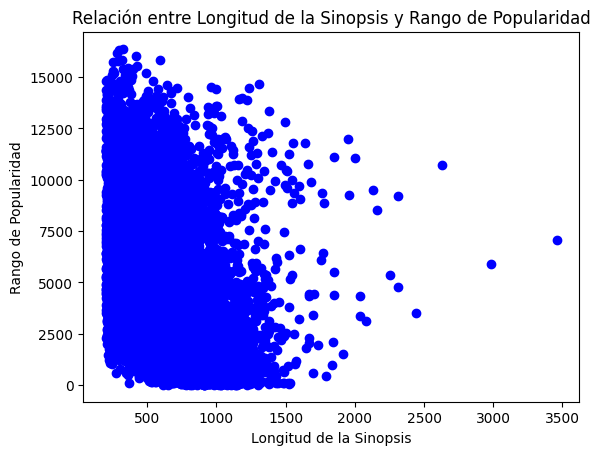

In [151]:
import matplotlib.pyplot as plt

plt.scatter(anime_dataset_filt['longitud_synopsis_caracteres'], anime_dataset_filt['popularity_rank'], color='blue')
plt.title('Relación entre Longitud de la Sinopsis y Rango de Popularidad')
plt.xlabel('Longitud de la Sinopsis')
plt.ylabel('Rango de Popularidad')
plt.show()

In [149]:
#@title Analisis de correlacion entre longitud de sinopsis y la puntuacion

correlacion_longSynop_populRank = anime_dataset_filt[['longitud_synopsis_caracteres', 'popularity_rank']].corr()
correlacion_longSynop_populRank

,longitud_synopsis_caracteres,popularity_rank
longitud_synopsis_caracteres,1.000000,-0.418476
popularity_rank,-0.418476,1.000000


In [25]:
#@title Analisis de correlacion entre longitud de sinopsis y la puntuacion
correlacion_longSynop_score = anime_dataset_filt[['longitud_synopsis_caracteres', 'score']].corr()


# plt.scatter(anime_dataset_filt['longitud_synopsis_caracteres'], anime_dataset_filt['score'], color='blue')
# plt.title('Relación entre Longitud de la Sinopsis y Rango de Popularidad')
# plt.xlabel('Longitud de la Sinopsis')
# plt.ylabel('La puntuación')
# plt.show()
anime_dataset_filt[['longitud_synopsis_caracteres', 'score']]
anime_dataset_filt.groupby('score').agg({'score':'count'})
correlacion_longSynop_score
# anime_dataset_filt[["genres", "anime_id"]]

,longitud_synopsis_caracteres,score
longitud_synopsis_caracteres,1.000000,0.302462
score,0.302462,1.000000


In [26]:
#@title Modelo de IA, no ejecutar si estas en vsc


# Cargar un pipeline de clasificación de emociones
classifier = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base", return_all_scores=True)

# Función para analizar emociones de un texto dado
def detectar_emociones(texto):
    resultados = classifier(texto)#aja yo estoy aqui
    # Procesar y mostrar los resultados de manera ordenada
    emociones = {resultado['label']: resultado['score'] for resultado in resultados[0]}
    emociones_ordenadas = sorted(emociones.items(), key=lambda item: item[1], reverse=True)

    return emociones_ordenadas

# Ejemplo de uso
texto = "I'm going under and this time I fear there's no one to save me"

emociones_detectadas = detectar_emociones(texto)

def print_results(emociones_detectadas):
  print("Emociones detectadas:")
  for emocion, puntaje in emociones_detectadas:
      print(f"{emocion}: {puntaje:.2f}")




/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


In [28]:
#@title Otro modelo no ejecutar


# Cargar el modelo y el tokenizador T5 ajustado para emociones
modelo_id = "mrm8488/t5-base-finetuned-emotion"
tokenizer = AutoTokenizer.from_pretrained(modelo_id)
modelo = AutoModelForSeq2SeqLM.from_pretrained(modelo_id)

# Función para detectar la emoción principal en un texto dado
def detectar_emocion_t5(texto):
    # Preprocesar el texto para el modelo T5
    entradas = tokenizer("emotion: " + texto, return_tensors="pt", padding=True)

    # Generar la emoción usando el modelo
    salida = modelo.generate(**entradas)

    # Decodificar la emoción generada
    emocion = tokenizer.decode(salida[0], skip_special_tokens=True)
    return emocion



tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/1.79k [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


pytorch_model.bin:   0%|          | 0.00/892M [00:00<?, ?B/s]

In [76]:
#@title Clasificacion por emociones

anime_dataset_filt[["title", "synopsis"]].head()
synopsis = anime_dataset_filt["synopsis"].head()
emociones_animes = pd.read_csv('anime_emotion.csv')
i = 0
for element in anime_dataset_filt[["anime_id","title", "synopsis"]][len(emociones_animes):].itertuples():
  i += 1
  emociones_animes.loc[len(emociones_animes)] = [element.anime_id, detectar_emocion_t5(element.synopsis)]
  print(i)

  emociones_animes.to_csv("anime_emotion.csv", index=False)

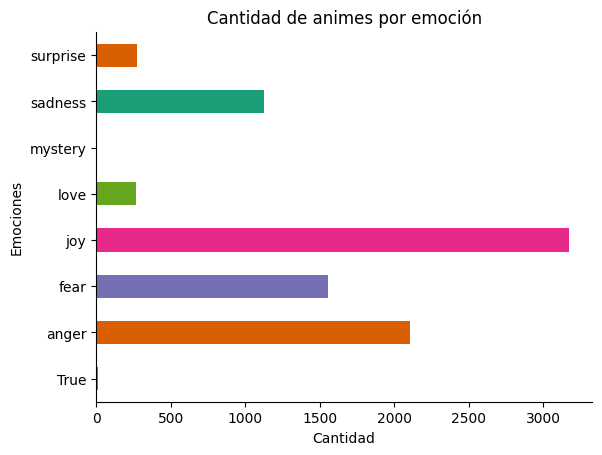

In [77]:
from matplotlib import pyplot as plt
import seaborn as sns
emociones_animes.groupby('emotion').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.ylabel('Emociones')
plt.xlabel('Cantidad')
plt.title('Cantidad de animes por emoción')
plt.show()

In [85]:

anime_dataset_filt['popularidad_categoria'] = pd.cut(anime_dataset_filt['popularity_rank'],bins=[0, 2000, 4000, 6000, 8000, anime_dataset_filt['popularity_rank'].max()],labels=['Muy Popular', 'Popular', 'Moderado', 'Bajo', 'Muy Bajo'])



# Función para obtener emociones para cada anime usando id_anime
def obtener_emociones(id_anime):
    # Filtramos emociones_animes para obtener las emociones asociadas a un id_anime
    emociones = emociones_animes[emociones_animes['anime_id'] == id_anime]['emotion'].tolist()
    return emociones

# Crear una lista para almacenar los resultados
emociones_popularidad = []

# Recorrer cada anime en anime_dataset_filt
for _, anime in anime_dataset_filt.iterrows():
    # Obtener las emociones del anime
    emociones = obtener_emociones(anime['anime_id'])
    # Obtener la categoría de popularidad
    categoria_popularidad = anime['popularidad_categoria']

    # Guardar las emociones junto con la categoría de popularidad
    for emocion in emociones:
        emociones_popularidad.append([categoria_popularidad, emocion])

# Convertir los resultados a un DataFrame
df_emociones_popularidad = pd.DataFrame(emociones_popularidad, columns=['popularidad_categoria', 'emociones'])

# Contar las emociones por popularidad
emotion_counts = df_emociones_popularidad.groupby(['popularidad_categoria', 'emociones']).size().unstack(fill_value=0)
categorias_ordenadas = ['Muy Popular', 'Popular', 'Moderado', 'Bajo', 'Muy Bajo']
emotion_counts.index = pd.CategoricalIndex(emotion_counts.index, categories=categorias_ordenadas, ordered=True)

emotion_counts = emotion_counts.sort_index()
emotion_counts

emociones,True,anger,fear,joy,love,sadness,surprise
popularidad_categoria,,,,,,,
Muy Popular,0,435,462,587,45,284,74
Popular,1,353,290,570,37,184,62
Moderado,3,358,225,427,46,182,38
Bajo,4,263,179,374,47,134,41
Muy Bajo,4,489,293,751,65,244,33


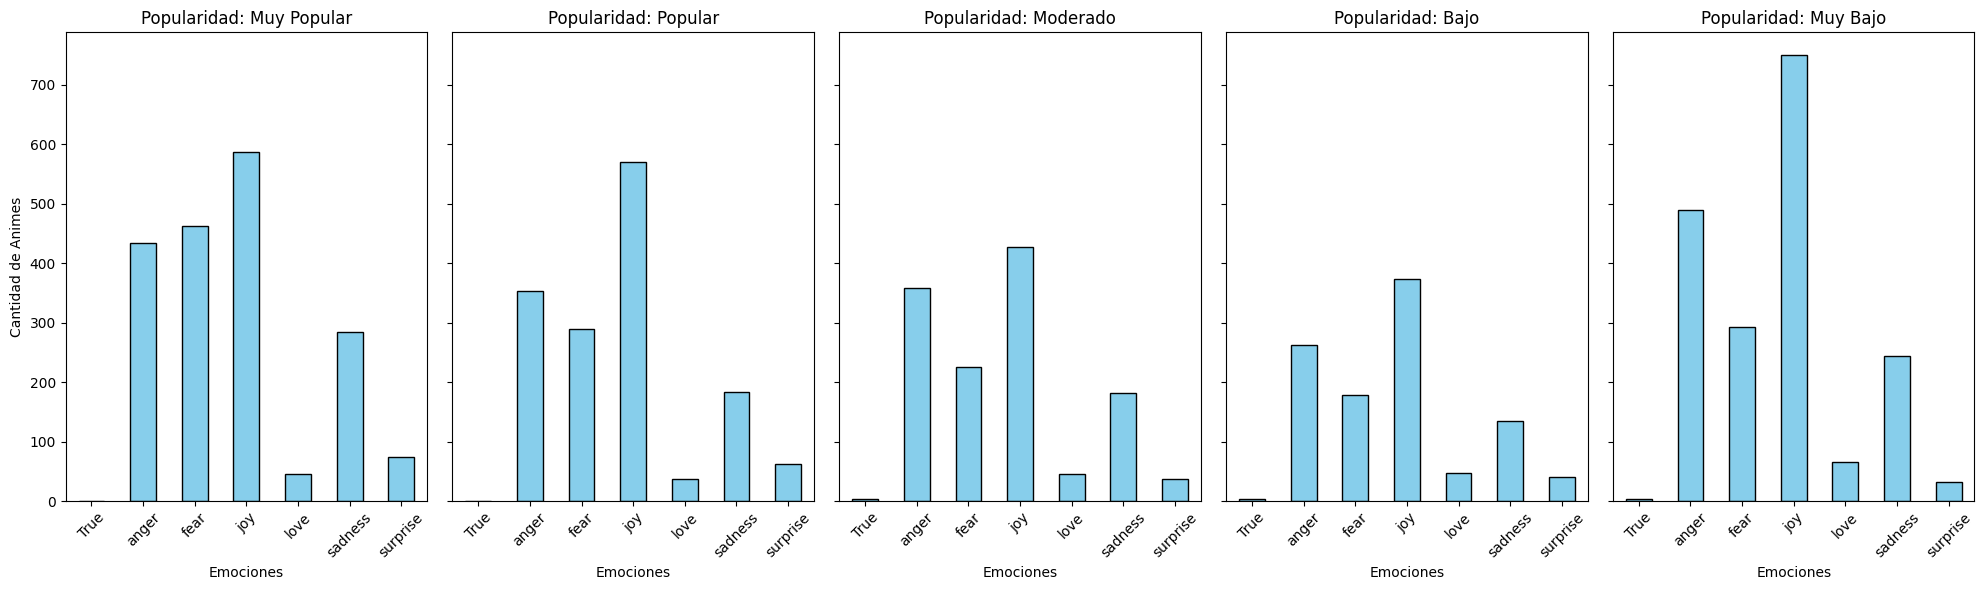

In [79]:
fig, axes = plt.subplots(1, 5, figsize=(20, 6), sharey=True)

# Crear un gráfico para cada categoría
for i, categoria in enumerate(emotion_counts.index):
    emotion_counts.loc[categoria].plot(kind='bar', ax=axes[i], color='skyblue', edgecolor='black')
    axes[i].set_title(f'Popularidad: {categoria}')
    axes[i].set_xlabel('Emociones')
    axes[i].set_ylabel('Cantidad de Animes')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

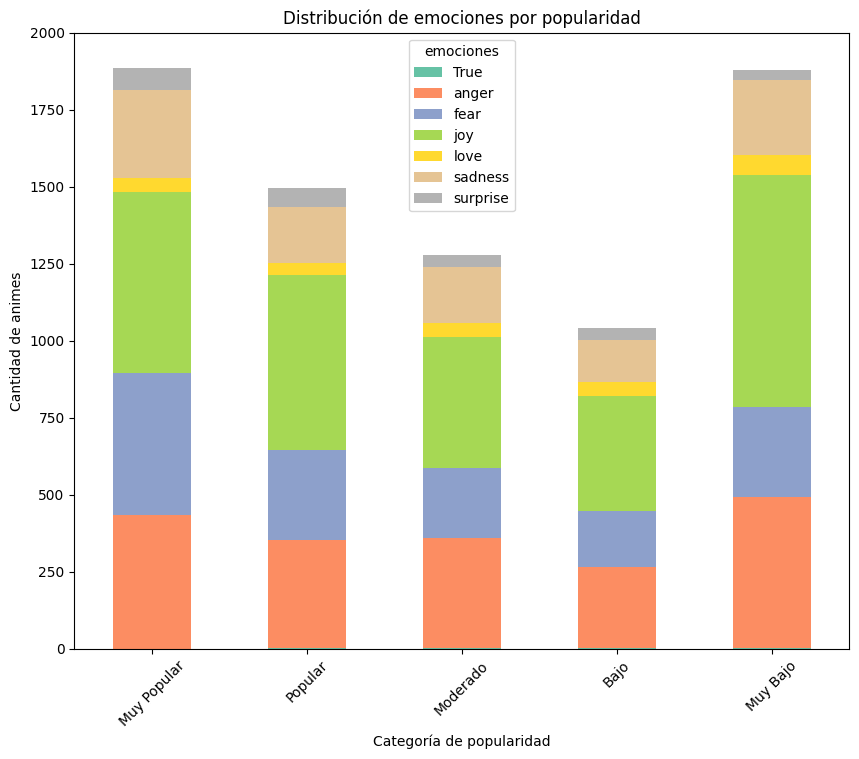

In [97]:
# Visualización: Gráfico de barras apiladas
emotion_counts.plot(kind='bar', stacked=True, figsize=(10, 8), colormap='Set2')
plt.title('Distribución de emociones por popularidad')
plt.xlabel('Categoría de popularidad')
plt.ylabel('Cantidad de animes')
plt.xticks(rotation=45)
plt.ylim(0, 2000)
plt.show()



In [103]:

# Crear las categorías de score en anime_dataset_filt
anime_dataset_filt['score_categoria'] = pd.cut(anime_dataset_filt['score'],
                                               bins=[0, 3, 5, 7, 8, 10],
                                               labels=['Bajo', 'Medio Bajo', 'Medio Alto', 'Alto', 'Excelente'])

# Función para obtener emociones para cada anime usando id_anime
def obtener_emociones(id_anime):
    # Filtramos emociones_animes para obtener las emociones asociadas a un id_anime
    emociones = emociones_animes[emociones_animes['anime_id'] == id_anime]['emotion'].tolist()
    return emociones

# Crear una lista para almacenar los resultados
emociones_score = []

# Recorrer cada anime en anime_dataset_filt
for _, anime in anime_dataset_filt.iterrows():
    # Obtener las emociones del anime
    emociones = obtener_emociones(anime['anime_id'])
    # Obtener la categoría de score
    categoria_score = anime['score_categoria']

    # Guardar las emociones junto con la categoría de score
    for emocion in emociones:
        emociones_score.append([categoria_score, emocion])

# Convertir los resultados a un DataFrame
df_emociones_score = pd.DataFrame(emociones_score, columns=['score_categoria', 'emociones'])

# Contar las emociones por score
emotion_counts_score = df_emociones_score.groupby(['score_categoria', 'emociones']).size().unstack(fill_value=0)

# Asegurar que los índices de score estén en el orden correcto
# Especificar el orden de las categorías de score
categorias_score_ordenadas = ['Bajo', 'Medio Bajo', 'Medio Alto', 'Alto', 'Excelente']
emotion_counts_score.index = pd.CategoricalIndex(emotion_counts_score.index, categories=categorias_score_ordenadas, ordered=True)

# Reorganizar el DataFrame para asegurar que el índice de score esté en el orden correcto
emotion_counts_score = emotion_counts_score.sort_index()
emotion_counts_score

emociones,True,anger,fear,joy,love,sadness,surprise
score_categoria,,,,,,,
Bajo,0,1,6,3,0,1,1
Medio Bajo,1,86,42,149,14,33,5
Medio Alto,10,1051,787,1491,155,535,128
Alto,1,648,511,888,63,384,99
Excelente,0,112,103,178,8,75,15


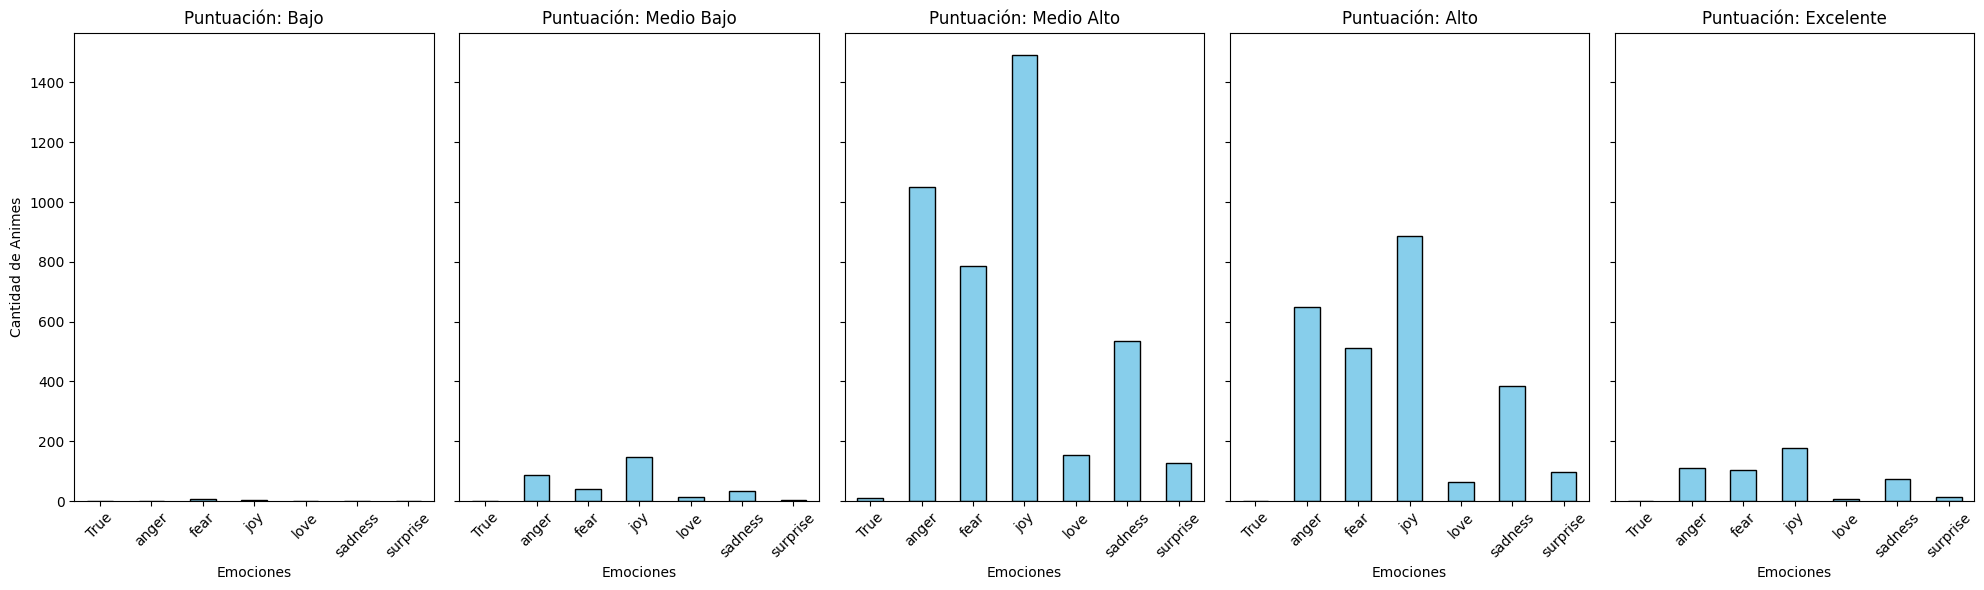

In [107]:
fig, axes = plt.subplots(1, 5, figsize=(20, 6), sharey=True)

# Crear un gráfico para cada categoría
for i, categoria in enumerate(emotion_counts_score.index):
    emotion_counts_score.loc[categoria].plot(kind='bar', ax=axes[i], color='skyblue', edgecolor='black')
    axes[i].set_title(f'Puntuación: {categoria}')
    axes[i].set_xlabel('Emociones')
    axes[i].set_ylabel('Cantidad de Animes')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

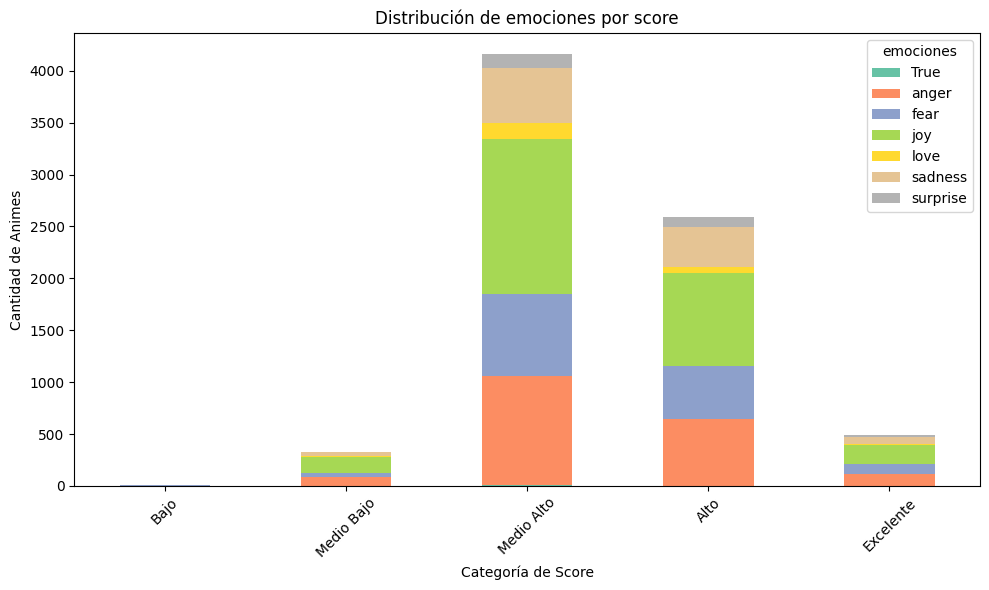

In [105]:
# Visualización: Gráfico de barras apiladas
ax = emotion_counts_score.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2')

# Establecer el título y las etiquetas
plt.title('Distribución de emociones por score')
plt.xlabel('Categoría de Score')
plt.ylabel('Cantidad de Animes')
# Rotar las etiquetas del eje X
plt.xticks(rotation=45)

# Mostrar el gráfico
plt.tight_layout()
plt.show()